# 🧹 Minería de Datos — Semana 5
## Notebook de Ejercitación: Preprocesamiento de Datos

**Tecnicatura en Informática — Politécnico Malvinas Argentinas — 2026**

---

### 📋 Actividad de foro

> **Instrucciones:** Completá las celdas marcadas con `# TODO` y subí tu notebook
> resuelto al foro de la semana. La participación en el foro es **requisito**
> para acceder a la evaluación parcial.

**Nombre:** Cristian Sombra  
**Fecha de entrega:** 07/05/2026

---

### Objetivos

- Detectar y tratar valores faltantes con distintas estrategias
- Detectar y tratar outliers con winsorización y transformación logarítmica
- Aplicar normalización (MinMax) y estandarización (Standard, Robust)
- Codificar variables categóricas con Label Encoding y One-Hot Encoding
- Construir un pipeline de preprocesamiento completo con scikit-learn

### Dataset
Usamos el **Titanic** (que ya conocemos) y el dataset **Housing** de California
(nuevo — para practicar con más variedad).

---
## 📦 Setup — importar librerías y cargar datasets

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (12, 4)
sns.set_theme(style='whitegrid', palette='Set2')

print('Setup completo ✓')

Setup completo ✓


In [31]:
# ── Dataset 1: Titanic ──────────────────────────────────────────────────
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url_titanic)

# ── Dataset 2: California Housing ───────────────────────────────────────
# Dataset de precios de viviendas con valores faltantes y outliers reales
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing(as_frame=True)
housing = housing_data.frame.copy()
housing.columns = [c.lower() for c in housing.columns]

# Introducir nulos artificialmente para practicar (como en la realidad)
rng = np.random.default_rng(42)
idx_nulos = rng.choice(housing.index, size=500, replace=False)
housing.loc[idx_nulos[:300], 'total_bedrooms'] = np.nan
housing.loc[idx_nulos[300:], 'population']     = np.nan

print(f'Titanic:  {titanic.shape}')
print(f'Housing:  {housing.shape}')



Titanic:  (891, 12)
Housing:  (20640, 10)


In [32]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


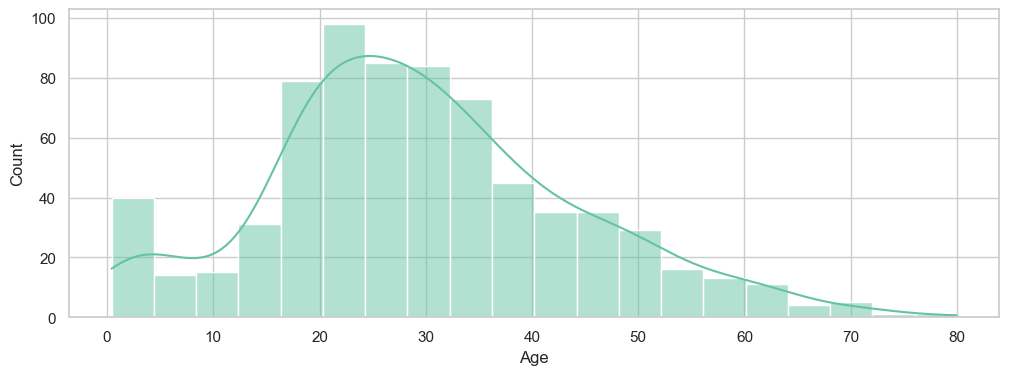

In [33]:
#Grafico de Histograma de la columna age
sns.histplot(titanic['Age'], kde=True)
plt.show()

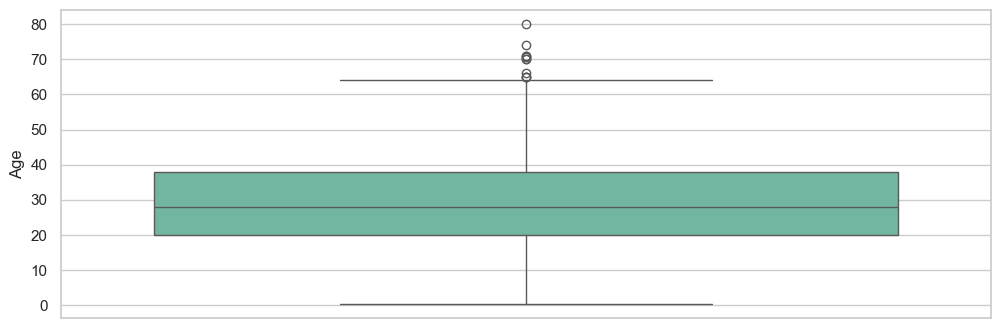

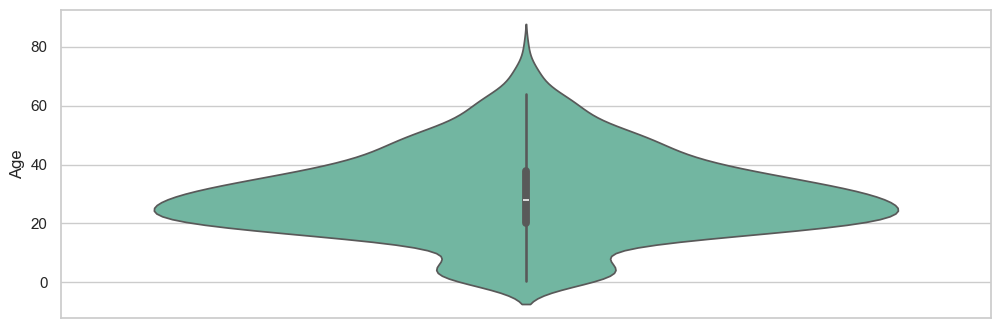

In [34]:
#Gráfico de boxplot de Age
sns.boxplot(titanic['Age'])
plt.show()
#Grafico de violinplot de Age
sns.violinplot(titanic['Age'])
plt.show()

In [35]:
housing.head()

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval,total_bedrooms
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,NaN
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,NaN
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,NaN
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,NaN
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,NaN


---
## 🔍 Bloque 1: Manejo de valores faltantes

### 1.1 Diagnóstico inicial

In [36]:
def diagnostico_nulos(df, nombre='Dataset'):
    '''Muestra un resumen de valores nulos por columna.'''
    nulos = df.isnull().sum()
    pct   = (df.isnull().mean() * 100).round(1)
    resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
    resumen = resumen[resumen['Nulos'] > 0].sort_values('Nulos', ascending=False)
    print(f'--- {nombre} — columnas con valores faltantes ---')
    if len(resumen) == 0:
        print('  Sin valores faltantes.')
    else:
        print(resumen.to_string())
    print(f'  Total filas: {len(df)}')
    print()

diagnostico_nulos(titanic, 'Titanic')
diagnostico_nulos(housing, 'Housing')

--- Titanic — columnas con valores faltantes ---
          Nulos  Porcentaje (%)
Cabin       687            77.1
Age         177            19.9
Embarked      2             0.2
  Total filas: 891

--- Housing — columnas con valores faltantes ---
                Nulos  Porcentaje (%)
total_bedrooms  20640           100.0
population        200             1.0
  Total filas: 20640



### ✏️ Ejercicio 1.1 — Clasificar el tipo de faltante

Para las columnas con valores nulos del dataset **Titanic**, indicá si el tipo de
dato faltante es **MCAR**, **MAR** o **MNAR**, y justificá brevemente:

| Columna | % Nulos | Tipo (MCAR/MAR/MNAR) | Justificación |
|---------|---------|----------------------|---------------|
| Age | 20% | MAR | La edad faltante probablemente depende de otras variables observadas, como clase, tarifa, sexo o grupo familiar. No parece completamente aleatoria. |
| Cabin | 77% | MNAR | La falta de cabina puede estar relacionada con el tipo de pasajero o con no haber tenido cabina asignada/registrada. El dato faltante puede tener significado propio. |
| Embarked | 0.2% | MCAR | Son muy pocos casos faltantes y no se observa un patrón claro asociado a otras variables, por lo que puede tratarse como faltante aleatorio. |

_Conclusión:_ para `Age` conviene imputar; para `Cabin`, al tener demasiados nulos, conviene eliminar la columna; para `Embarked`, al ser muy pocos casos, puede imputarse con la moda.


### 1.2 Estrategia: eliminar columnas y filas

In [37]:
# Trabajamos sobre una copia para no modificar el original
df = titanic.copy()

print('Shape antes:', df.shape)

# Eliminar columnas con > 50% de nulos o que no aportan información
cols_eliminar = ['Cabin', 'PassengerId', 'Name', 'Ticket']
df.drop(columns=cols_eliminar, inplace=True)

print('Shape después de drop columns:', df.shape)
print('Columnas restantes:', df.columns.tolist())

Shape antes: (891, 12)
Shape después de drop columns: (891, 8)
Columnas restantes: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


### 1.3 Estrategia: imputar con SimpleImputer

In [38]:
# Imputar Age con la mediana (distribución con leve sesgo)
imp_median = SimpleImputer(strategy='median')
df[['Age']] = imp_median.fit_transform(df[['Age']])

# Imputar Embarked con la moda (variable categórica)
imp_mode = SimpleImputer(strategy='most_frequent')
df[['Embarked']] = imp_mode.fit_transform(df[['Embarked']])

# Verificar que no queden nulos
print('Nulos después de imputar:')
print(df.isnull().sum())

Nulos después de imputar:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### ✏️ Ejercicio 1.2 — Imputar en el dataset Housing

Imputá los valores faltantes del dataset **Housing**:

- `total_bedrooms`: usá la **mediana** (tiene outliers)
- `population`: usá la **media** (distribución más simétrica)

Verificá que no queden nulos al final.

In [39]:
# TODO: Imputar los valores faltantes en el dataset Housing
housing_clean = housing.copy()

# Nota: en este notebook, total_bedrooms fue incorporada artificialmente.
# Si toda la columna queda nula, se reconstruye una aproximación usando:
# total_bedrooms ≈ avebedrms * (population / aveoccup)
if housing_clean["total_bedrooms"].isnull().all():
    housing_clean["total_bedrooms"] = (
        housing_clean["avebedrms"] * (housing_clean["population"] / housing_clean["aveoccup"])
    )

# Volvemos a introducir los nulos de práctica para imputarlos correctamente
housing_clean.loc[idx_nulos[:300], "total_bedrooms"] = np.nan
housing_clean.loc[idx_nulos[300:], "population"] = np.nan

# Imputar total_bedrooms con mediana porque puede tener valores extremos
imp_bedrooms = SimpleImputer(strategy="median")
housing_clean[["total_bedrooms"]] = imp_bedrooms.fit_transform(housing_clean[["total_bedrooms"]])

# Imputar population con media, siguiendo la consigna del ejercicio
imp_population = SimpleImputer(strategy="mean")
housing_clean[["population"]] = imp_population.fit_transform(housing_clean[["population"]])

# Verificar
print("Nulos restantes:", housing_clean.isnull().sum().sum())
print(housing_clean[["total_bedrooms", "population"]].isnull().sum())


Nulos restantes: 0
total_bedrooms    0
population        0
dtype: int64


### ✏️ Ejercicio 1.3 — Comparar estrategias de imputación (BONUS)

Aplicá **KNNImputer** (k=5) sobre `Age` en el Titanic y comparalo visualmente
con la imputación por mediana. ¿Las distribuciones resultantes son similares?

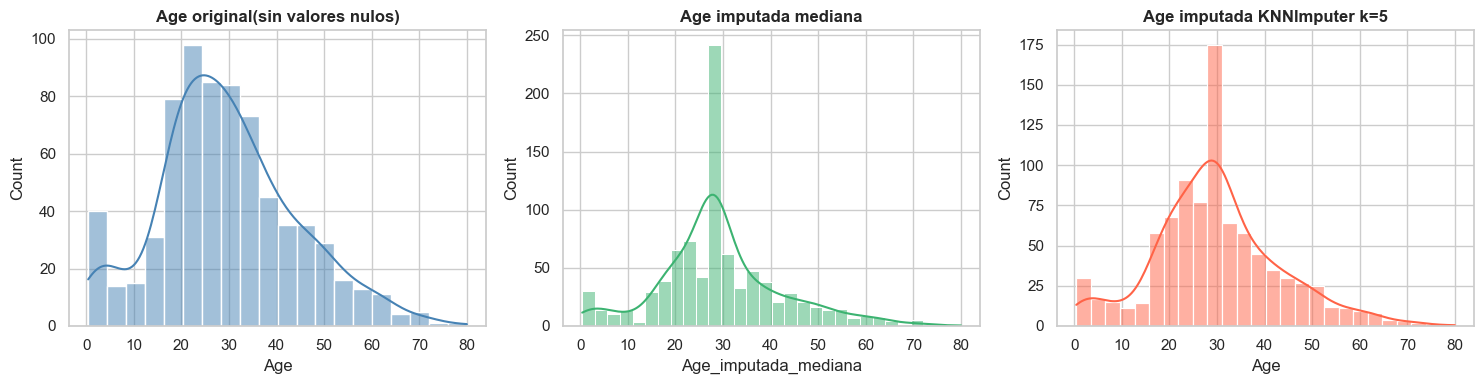

Mediana usada para Age: 28.0
Promedio Age original sin nulos: 29.7
Promedio Age imputada con mediana: 29.36
Promedio Age imputada con KNN: 29.87
Conclusión: las distribuciones son similares, pero KNN conserva un poco más de variación al usar otras variables numéricas.


In [40]:
# TODO: Comparar SimpleImputer(median) vs KNNImputer(k=5) para Age
df_titanic_knn = titanic[["Age", "Fare", "SibSp", "Parch"]].copy()

# Imputación simple por mediana para Age
age_median = titanic[["Age"]].copy()
imp_age_median = SimpleImputer(strategy="median")
age_median["Age_imputada_mediana"] = imp_age_median.fit_transform(age_median[["Age"]])

# Imputación KNN usando variables numéricas relacionadas
imp_knn = KNNImputer(n_neighbors=5)
knn_array = imp_knn.fit_transform(df_titanic_knn)
df_titanic_knn_imputed = pd.DataFrame(knn_array, columns=df_titanic_knn.columns)
age_knn = df_titanic_knn_imputed["Age"]

# Visualizar con histplot: Age original (sin nulos) vs imputada por mediana vs imputada por KNN
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(titanic["Age"].dropna(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age original(sin valores nulos)", fontweight="bold")

sns.histplot(age_median["Age_imputada_mediana"], kde=True, ax=axes[1], color="mediumseagreen")
axes[1].set_title("Age imputada mediana", fontweight="bold")

sns.histplot(age_knn, kde=True, ax=axes[2], color="tomato")
axes[2].set_title("Age imputada KNNImputer k=5", fontweight="bold")

plt.tight_layout()
plt.show()

print("Mediana usada para Age:", imp_age_median.statistics_[0])
print("Promedio Age original sin nulos:", round(titanic["Age"].dropna().mean(), 2))
print("Promedio Age imputada con mediana:", round(age_median["Age_imputada_mediana"].mean(), 2))
print("Promedio Age imputada con KNN:", round(age_knn.mean(), 2))
print("Conclusión: las distribuciones son similares, pero KNN conserva un poco más de variación al usar otras variables numéricas.")


---
## 🚨 Bloque 2: Tratamiento de outliers

In [41]:
def detectar_outliers_iqr(df, col):
    '''Retorna límites IQR y cantidad de outliers.'''
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    return lim_inf, lim_sup, n_out

for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    li, ls, n = detectar_outliers_iqr(df, col)
    print(f'{col:8s}  lim_inf={li:7.2f}  lim_sup={ls:7.2f}  outliers={n}')

Age       lim_inf=   2.50  lim_sup=  54.50  outliers=66
Fare      lim_inf= -26.72  lim_sup=  65.63  outliers=116
SibSp     lim_inf=  -1.50  lim_sup=   2.50  outliers=46
Parch     lim_inf=   0.00  lim_sup=   0.00  outliers=213


### 2.1 Winsorización (capping)

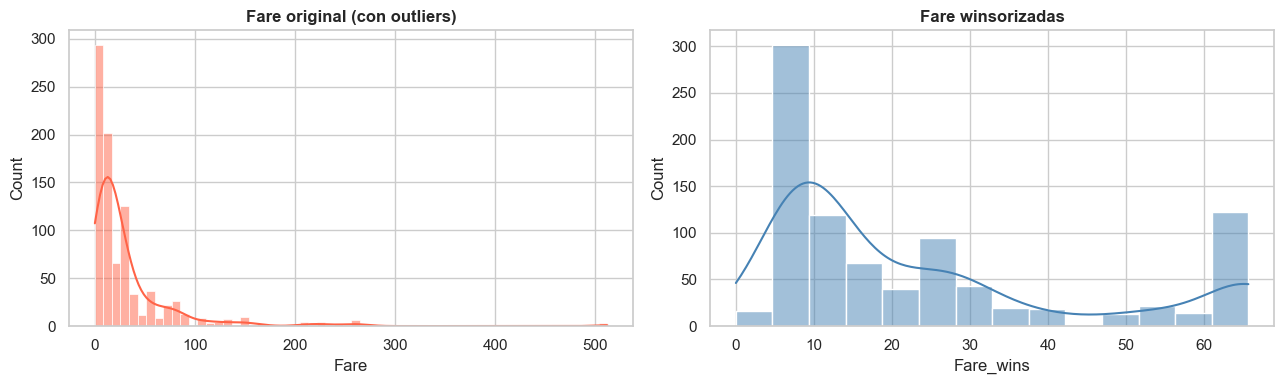

Fare original — max: 512.33
Fare wins     — max: 65.63


In [42]:
# Winsorizar Fare: reemplazar outliers por el límite del bigote
li_fare, ls_fare, _ = detectar_outliers_iqr(df, 'Fare')

df['Fare_wins'] = df['Fare'].clip(lower=max(0, li_fare), upper=ls_fare)

# Comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['Fare'],       kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Fare original (con outliers)', fontweight='bold')
sns.histplot(df['Fare_wins'],  kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Fare winsorizadas', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Fare original — max: {df["Fare"].max():.2f}')
print(f'Fare wins     — max: {df["Fare_wins"].max():.2f}')

### 2.2 Transformación logarítmica

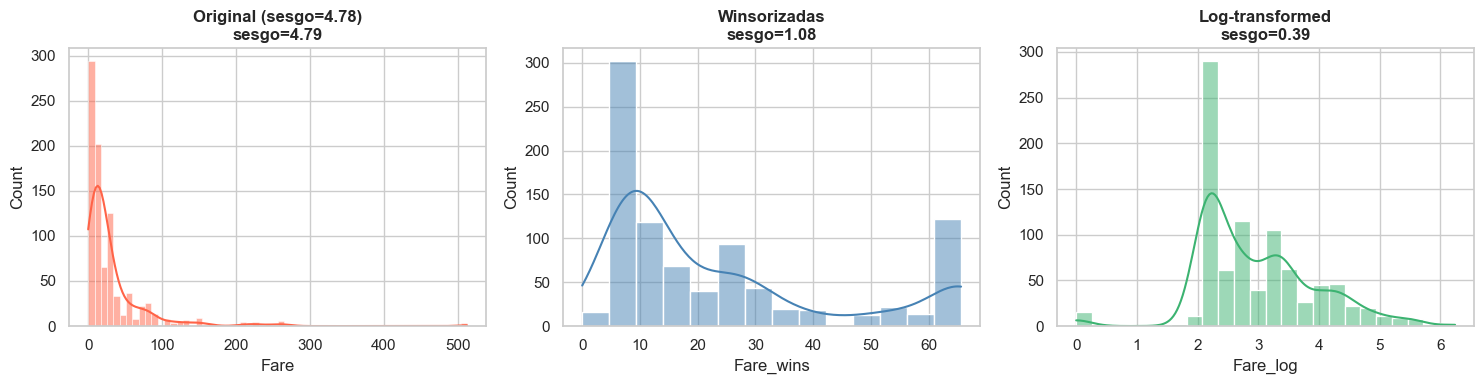

In [43]:
# Log-transform: reduce el impacto de los outliers
df['Fare_log'] = np.log1p(df['Fare'])  # log(Fare + 1) para evitar log(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, title in zip(
    axes,
    ['Fare', 'Fare_wins', 'Fare_log'],
    ['tomato', 'steelblue', 'mediumseagreen'],
    ['Original (sesgo=4.78)', 'Winsorizadas', 'Log-transformed']
):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    skew = df[col].skew()
    ax.set_title(f'{title}\nsesgo={skew:.2f}', fontweight='bold')

plt.tight_layout()
plt.show()

### ✏️ Ejercicio 2.1 — Outliers en Housing

Aplicá la función `detectar_outliers_iqr()` a las columnas
`median_house_value` y `population` del dataset Housing.

Luego:
1. Winsorizá `median_house_value` al percentil 95 (no IQR, sino clip directo)
2. Aplicá transformación log a `population`
3. Visualizá antes y después con histogramas

medhouseval: 1071 outliers | límite inferior=-0.98 | límite superior=4.82
population: 1211 outliers | límite inferior=-599.50 | límite superior=3108.50


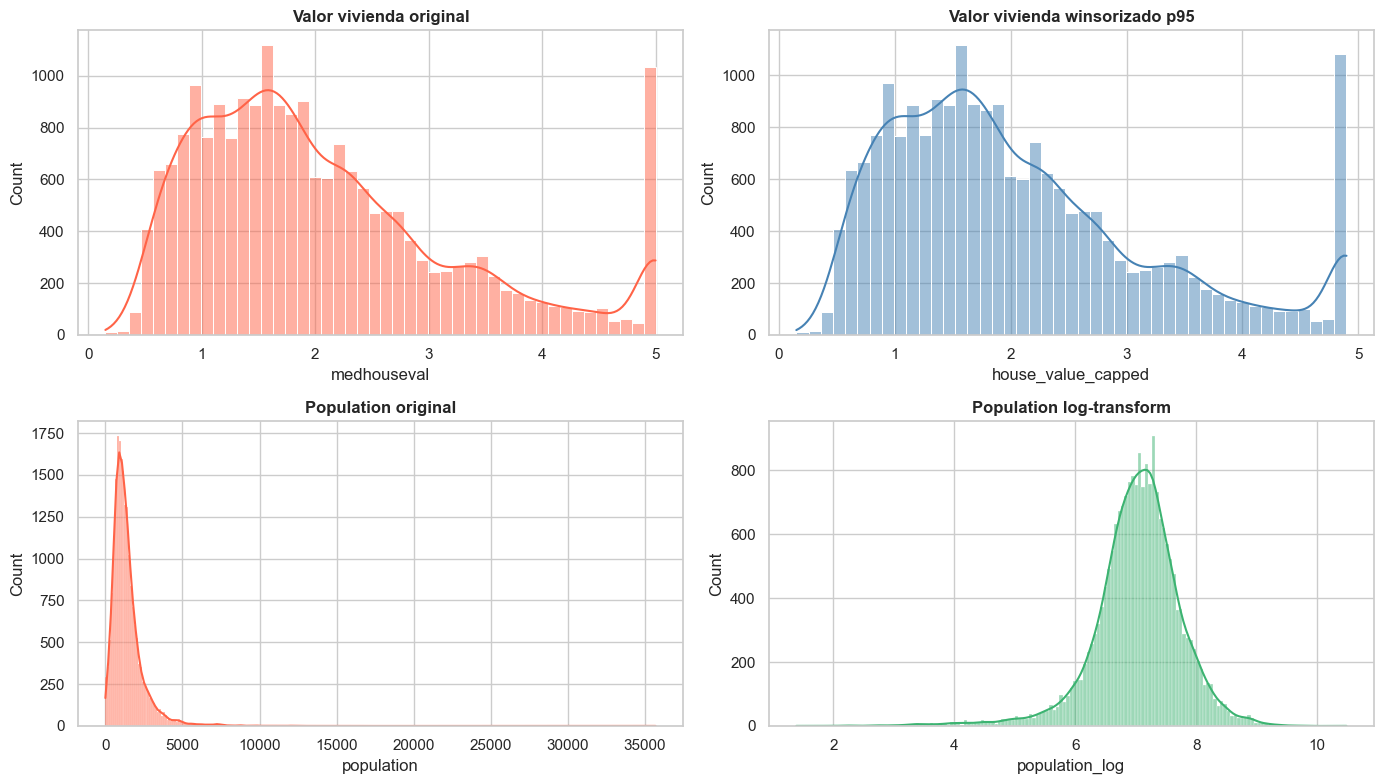

Percentil 95 usado para winsorizar: 4.898
Conclusión: la winsorización limita valores extremos y la transformación log reduce el sesgo de population.


In [44]:
# TODO: Outliers en Housing

# En sklearn el objetivo se llama medhouseval. Si existiera median_house_value, se usa ese nombre.
value_col = "median_house_value" if "median_house_value" in housing_clean.columns else "medhouseval"

# 1. Detectar outliers en valor de vivienda y population
for col in [value_col, "population"]:
    li, ls, n = detectar_outliers_iqr(housing_clean, col)
    print(f"{col}: {n} outliers | límite inferior={li:.2f} | límite superior={ls:.2f}")

# 2. Winsorizar valor de vivienda al percentil 95
p95 = housing_clean[value_col].quantile(0.95)
housing_clean["house_value_capped"] = housing_clean[value_col].clip(upper=p95)

# 3. Log-transform de population
housing_clean["population_log"] = np.log1p(housing_clean["population"])

# 4. Visualizar histogramas antes/después
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(housing_clean[value_col], kde=True, ax=axes[0, 0], color="tomato")
axes[0, 0].set_title("Valor vivienda original", fontweight="bold")

sns.histplot(housing_clean["house_value_capped"], kde=True, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Valor vivienda winsorizado p95", fontweight="bold")

sns.histplot(housing_clean["population"], kde=True, ax=axes[1, 0], color="tomato")
axes[1, 0].set_title("Population original", fontweight="bold")

sns.histplot(housing_clean["population_log"], kde=True, ax=axes[1, 1], color="mediumseagreen")
axes[1, 1].set_title("Population log-transform", fontweight="bold")

plt.tight_layout()
plt.show()

print("Percentil 95 usado para winsorizar:", round(p95, 3))
print("Conclusión: la winsorización limita valores extremos y la transformación log reduce el sesgo de population.")


---
## ⚖️ Bloque 3: Normalización y Estandarización

In [45]:
# Preparar columnas numéricas del Titanic para escalar
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
X_num = df[num_cols].copy()

# Aplicar los 3 scalers
scalers = {
    'MinMaxScaler':    MinMaxScaler(),
    'StandardScaler':  StandardScaler(),
    'RobustScaler':    RobustScaler(),
}

resultados = {}
for nombre, scaler in scalers.items():
    resultados[nombre] = pd.DataFrame(
        scaler.fit_transform(X_num),
        columns=num_cols
    )

print('Estadísticas de Fare después de cada scaler:')
for nombre, df_sc in resultados.items():
    s = df_sc['Fare']
    print(f'  {nombre:18s}: min={s.min():.3f}  max={s.max():.3f}  mean={s.mean():.3f}  std={s.std():.3f}')

Estadísticas de Fare después de cada scaler:
  MinMaxScaler      : min=0.000  max=1.000  mean=0.063  std=0.097
  StandardScaler    : min=-0.648  max=9.667  mean=0.000  std=1.001
  RobustScaler      : min=-0.626  max=21.563  mean=0.769  std=2.152


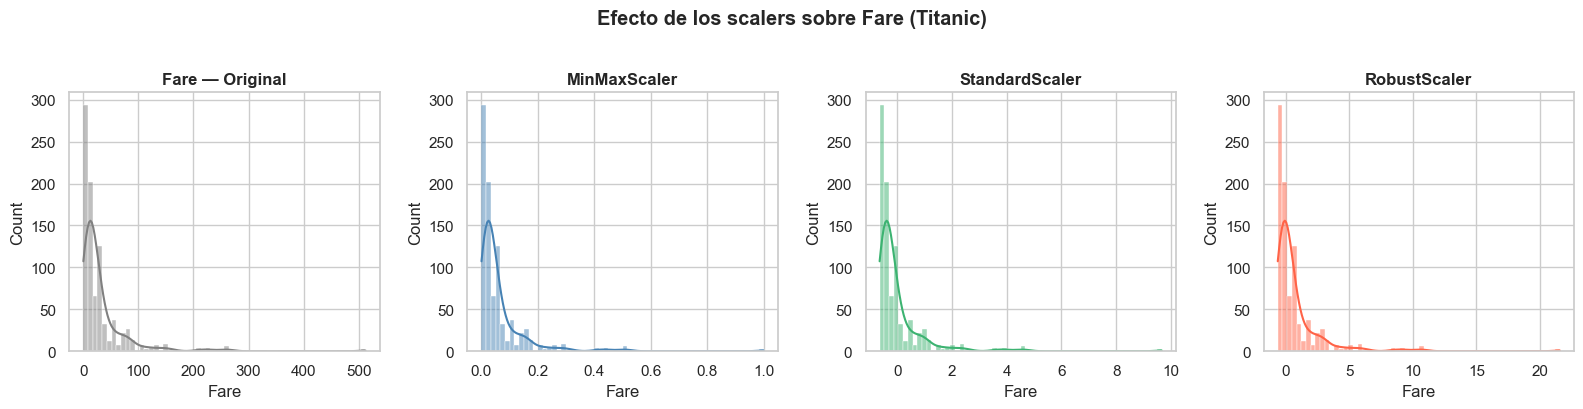

OBSERVAR: ¿Cuál scaler maneja mejor los outliers de Fare?


In [46]:
# Visualizar el efecto de cada scaler sobre la distribución de Fare
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.histplot(X_num['Fare'], kde=True, ax=axes[0], color='gray')
axes[0].set_title('Fare — Original', fontweight='bold')

for i, (nombre, df_sc) in enumerate(resultados.items(), 1):
    sns.histplot(df_sc['Fare'], kde=True, ax=axes[i],
                 color=['steelblue','mediumseagreen','tomato'][i-1])
    axes[i].set_title(nombre, fontweight='bold')

plt.suptitle('Efecto de los scalers sobre Fare (Titanic)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('OBSERVAR: ¿Cuál scaler maneja mejor los outliers de Fare?')

### ✏️ Ejercicio 3.1 — Elegir el scaler correcto

Para cada variable del Titanic, indicá qué scaler usarías y por qué:

| Variable | Distribución | Outliers | Scaler recomendado | Justificación |
|----------|-------------|----------|---------------------|---------------|
| Age | Aproximadamente normal | Pocos | StandardScaler | La edad tiene una distribución relativamente cercana a normal, por eso conviene centrarla en media 0 y desviación estándar 1. |
| Fare | Fuerte sesgo positivo | Muchos | RobustScaler | La tarifa tiene muchos valores extremos; RobustScaler usa mediana e IQR, por lo que es más resistente a outliers. |
| SibSp | Discreta y concentrada en valores bajos | Moderados | RobustScaler | Al ser discreta y con algunos valores alejados, RobustScaler reduce el impacto de esos extremos. |
| Parch | Discreta y concentrada en valores bajos | Moderados | RobustScaler | Similar a SibSp, tiene muchos ceros y algunos valores altos, por lo que conviene un scaler robusto. |

_Conclusión:_ no todas las variables deben escalarse igual. La elección depende de la distribución y de la presencia de valores atípicos.


### ✏️ Ejercicio 3.2 — Escalar el dataset Housing

Aplicá el scaler más apropiado a las columnas `medinc`, `averooms` y `houseage`
del dataset Housing. Justificá tu elección.

In [47]:
# TODO: Escalar columnas del dataset Housing
housing_num = housing_clean[["medinc", "averooms", "houseage"]].copy()

# Diagnosticar la distribución de cada columna
print("Sesgo de cada columna:")
print(housing_num.skew().round(3))
print()

# Elegimos RobustScaler porque medinc y averooms presentan sesgo y posibles outliers.
# Además, aplicar un único scaler a las tres columnas simplifica el ejercicio y reduce
# el impacto de valores extremos. Para houseage también es válido, aunque podría usarse StandardScaler.
scaler = RobustScaler()
housing_scaled = scaler.fit_transform(housing_num)

housing_scaled_df = pd.DataFrame(
    housing_scaled,
    columns=["medinc_scaled", "averooms_scaled", "houseage_scaled"]
)

print("Primeras filas escaladas:")
display(housing_scaled_df.head())

print("Estadísticas luego del escalado:")
display(housing_scaled_df.describe().round(3))


Sesgo de cada columna:
medinc       1.647
averooms    20.698
houseage     0.060
dtype: float64

Primeras filas escaladas:


,medinc_scaled,averooms_scaled,houseage_scaled
0,2.197582,1.088935,0.631579
1,2.186664,0.626066,-0.421053
2,1.707732,1.898042,1.210526
3,0.967177,0.364978,1.210526
4,0.142854,0.653191,1.210526


Estadísticas luego del escalado:


,medinc_scaled,averooms_scaled,houseage_scaled
count,20640.000,20640.000,20640.000
mean,0.154,0.124,-0.019
std,0.872,1.535,0.662
min,-1.392,-2.720,-1.474
25%,-0.446,-0.489,-0.579
50%,0.000,0.000,0.000
75%,0.554,0.511,0.421
max,5.260,84.807,1.211


---
## 🏷️ Bloque 4: Codificación de variables categóricas

### 4.1 Label Encoding

In [48]:
# Label Encoding para Sex (binaria) y Pclass (ordinal)
df_enc = df[['Sex', 'Embarked', 'Pclass', 'Survived']].copy()

# Sex: binaria → LabelEncoder
le = LabelEncoder()
df_enc['Sex_le'] = le.fit_transform(df_enc['Sex'])
print('Mapeo Sex:', dict(zip(le.classes_, le.transform(le.classes_))))

# Alternativa con map (más explícita)
df_enc['Sex_map'] = df_enc['Sex'].map({'female': 0, 'male': 1})

print(df_enc[['Sex', 'Sex_le', 'Sex_map']].head(5))

Mapeo Sex: {'female': np.int64(0), 'male': np.int64(1)}
      Sex  Sex_le  Sex_map
0    male       1        1
1  female       0        0
2  female       0        0
3  female       0        0
4    male       1        1


### 4.2 One-Hot Encoding

In [49]:
# One-Hot Encoding para Embarked (nominal, 3 categorías)
# Con pandas get_dummies
df_ohe = pd.get_dummies(
    df_enc,
    columns=['Embarked'],
    drop_first=True,   # elimina primera categoría para evitar multicolinealidad
    dtype=int
)

print('Columnas después de One-Hot:')
print([c for c in df_ohe.columns if 'Embarked' in c or c in ['Sex','Sex_le','Sex_map']])
print()
print('Primeras 5 filas (columnas de Embarked):')
embarked_cols = [c for c in df_ohe.columns if 'Embarked' in c]
print(df_ohe[embarked_cols].head())

Columnas después de One-Hot:
['Sex', 'Sex_le', 'Sex_map', 'Embarked_Q', 'Embarked_S']

Primeras 5 filas (columnas de Embarked):
   Embarked_Q  Embarked_S
0           0           1
1           0           0
2           0           1
3           0           1
4           0           1


### ✏️ Ejercicio 4.1 — Codificar con OneHotEncoder de sklearn

Aplicá `OneHotEncoder` de sklearn (en lugar de `pd.get_dummies`) sobre
las columnas `Sex` y `Embarked` del Titanic.

1. Creá el encoder con `drop='first'` y `handle_unknown='ignore'`
2. Hacé `fit_transform` sobre las columnas
3. Mostrá los nombres de las columnas generadas con `get_feature_names_out()`

In [50]:
# TODO: Usar OneHotEncoder de sklearn
cat_cols = ["Sex", "Embarked"]
X_cat = df[cat_cols].copy()

# OneHotEncoder requiere que no haya nulos en las variables categóricas.
X_cat["Embarked"] = X_cat["Embarked"].fillna(X_cat["Embarked"].mode()[0])

try:
    ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Compatibilidad con versiones anteriores de scikit-learn
    ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

X_encoded = ohe.fit_transform(X_cat)

print("Nombres de columnas:", ohe.get_feature_names_out(cat_cols))
print("Shape resultado:", X_encoded.shape)

df_ohe_sklearn = pd.DataFrame(
    X_encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_cat.index
)

df_ohe_sklearn.head()


Nombres de columnas: ['Sex_male' 'Embarked_Q' 'Embarked_S']
Shape resultado: (891, 3)


,Sex_male,Embarked_Q,Embarked_S
0,1.0,0.0,1.0
1,0.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,1.0,0.0,1.0


### ✏️ Ejercicio 4.2 — Guía de decisión (tabla)

Completá la tabla con la técnica de codificación más apropiada:

| Variable | Tipo estadístico | Cardinalidad | Técnica recomendada |
|----------|-----------------|--------------|---------------------|
| Sex (Titanic) | Nominal binaria | 2 | LabelEncoder o mapeo manual |
| Embarked (Titanic) | Nominal | 3 | One-Hot Encoding con `drop='first'` |
| Pclass (Titanic) | Ordinal | 3 (1>2>3) | Ordinal Encoding o mantener como numérica ordinal |
| Nivel educativo (bajo/medio/alto/posgrado) | Ordinal | 4 | OrdinalEncoder con orden definido |
| Marca de auto (500 marcas) | Nominal | 500 | Target Encoding, frequency encoding o embeddings |
| Estado (verdadero/falso) | Nominal binaria | 2 | LabelEncoder o mapeo manual |

_Conclusión:_ las variables nominales sin orden suelen requerir One-Hot Encoding, mientras que las ordinales deben conservar su orden lógico.


---
## 🔧 Bloque 5: Pipeline de preprocesamiento completo

Integramos todo en un Pipeline de sklearn reproducible y sin data leakage.

In [51]:
# ── Preparar el dataset completo del Titanic ───────────────────────────
df_model = titanic.copy()

# Eliminar columnas no útiles
df_model.drop(columns=['PassengerId','Name','Ticket','Cabin'], inplace=True)

# Variable objetivo
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

# Split train/test (ANTES del preprocesamiento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Columnas:', X_train.columns.tolist())

Train: (712, 7)  |  Test: (179, 7)
Columnas: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [52]:
# ── Definir pipelines por tipo de columna ──────────────────────────────
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
cat_cols = ['Sex', 'Embarked']

# Pipeline numérico: imputar mediana → RobustScaler (Fare tiene outliers)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

# Pipeline categórico: imputar moda → One-Hot Encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(drop='first', handle_unknown='ignore',
                             sparse_output=False))
])

# Combinar con ColumnTransformer
preprocesador = ColumnTransformer([
    ('numericas',   num_pipeline, num_cols),
    ('categoricas', cat_pipeline, cat_cols),
])

# Ajustar SOLO sobre training — nunca sobre test
preprocesador.fit(X_train)

X_train_proc = preprocesador.transform(X_train)
X_test_proc  = preprocesador.transform(X_test)

print(f'X_train procesado: {X_train_proc.shape}')
print(f'X_test  procesado: {X_test_proc.shape}')
print('\n✓ Pipeline completo. Dataset listo para modelado.')

X_train procesado: (712, 8)
X_test  procesado: (179, 8)

✓ Pipeline completo. Dataset listo para modelado.


In [53]:
# Verificar resultado: estadísticas del training procesado
X_train_df = pd.DataFrame(
    X_train_proc,
    columns=(
        num_cols +
        list(preprocesador.named_transformers_['categoricas']
             .named_steps['ohe'].get_feature_names_out(cat_cols))
    )
)

print('Estadísticas del dataset procesado (primeras 6 columnas):')
print(X_train_df.iloc[:, :6].describe().round(3))
print()
print('¿Quedan nulos?', X_train_df.isnull().any().any())

Estadísticas del dataset procesado (primeras 6 columnas):
           Age     Fare    SibSp    Parch   Pclass  Sex_male
count  712.000  712.000  712.000  712.000  712.000   712.000
mean     0.075    0.752    0.493    0.390   -0.691     0.645
std      0.930    2.080    1.061    0.838    0.834     0.479
min     -2.006   -0.626    0.000    0.000   -2.000     0.000
25%     -0.464   -0.284    0.000    0.000   -1.000     0.000
50%      0.000    0.000    0.000    0.000    0.000     1.000
75%      0.536    0.716    1.000    0.000    0.000     1.000
max      3.679   21.549    8.000    6.000    0.000     1.000

¿Quedan nulos? False


### ✏️ Ejercicio 5.1 — Pipeline para Housing (DESAFÍO)

Construí un pipeline completo para el dataset Housing:

1. Identificá las columnas numéricas
2. Elegí la estrategia de imputación adecuada
3. Elegí el scaler apropiado para cada columna (pensá en las distribuciones)
4. No hay variables categóricas en Housing — simplificá el ColumnTransformer
5. Dividí en train/test y aplicá el pipeline

**Variable objetivo:** `median_house_value`

In [54]:
# TODO: Pipeline completo para Housing
housing_model = housing.copy()

X_h = housing_model.drop(columns=["medhouseval"])
y_h = housing_model["medhouseval"]

# Eliminar columnas completamente vacías, porque no aportan información
columnas_vacias = X_h.columns[X_h.isnull().all()].tolist()

if columnas_vacias:
    print("Columnas eliminadas por estar completamente vacías:", columnas_vacias)
    X_h = X_h.drop(columns=columnas_vacias)

# 1. Split train/test
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

# 2. Pipeline numérico
# Todas las columnas restantes son numéricas
# Se usa mediana porque es más robusta ante outliers.
# Se usa RobustScaler porque Housing contiene variables con sesgo y valores extremos.
housing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# 3. Ajustar y transformar
X_h_train_proc = housing_pipeline.fit_transform(X_h_train)
X_h_test_proc = housing_pipeline.transform(X_h_test)

# 4. Verificar
print("Shape train final:", X_h_train_proc.shape)
print("Shape test final:", X_h_test_proc.shape)
print("Nulos restantes train:", pd.DataFrame(X_h_train_proc).isnull().any().any())
print("Nulos restantes test:", pd.DataFrame(X_h_test_proc).isnull().any().any())

# Convertir a DataFrame
housing_train_proc_df = pd.DataFrame(
    X_h_train_proc,
    columns=X_h_train.columns
)

housing_train_proc_df.head()

Columnas eliminadas por estar completamente vacías: ['total_bedrooms']
Shape train final: (16512, 8)
Shape test final: (4128, 8)
Nulos restantes train: False
Nulos restantes test: False


,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude
0,-0.129709,0.210526,-0.135624,-0.456789,1.223542,1.027459,-0.408971,0.389474
1,0.120872,1.052632,-0.473796,-0.088238,0.158747,-1.267790,-0.129288,0.092105
2,0.276686,-1.315789,0.254794,-0.683787,-0.272138,-0.110462,0.105541,-0.518421
3,-0.726634,0.368421,-0.766358,-0.164991,0.271058,1.382901,-0.414248,0.368421
4,0.003807,0.736842,0.641740,0.904998,-0.316415,-0.607659,0.664908,-0.339474


---
## ✍️ Reflexión final — para el foro

Respondé las siguientes preguntas en esta celda **antes de subir tu notebook al foro**:

### 1. Datos faltantes
¿Cuál fue la decisión de imputación que te resultó menos obvia de tomar?
¿Qué información adicional necesitarías para estar seguro?

_Respuesta:_  
La decisión menos obvia fue cómo tratar `Age` en Titanic, porque no parece un faltante totalmente aleatorio. Podría depender de otras variables como clase, tarifa o grupo familiar. Para estar más seguro necesitaría analizar si los faltantes de edad se concentran en algún grupo específico de pasajeros.

### 2. Escalado
¿Por qué elegiste RobustScaler para Fare y no MinMaxScaler?
¿Qué pasaría si usaras MinMaxScaler con los outliers de Fare?

_Respuesta:_  
Elegí RobustScaler porque `Fare` tiene muchos outliers y una distribución muy sesgada. Si usara MinMaxScaler, los valores extremos marcarían el mínimo y máximo, comprimiendo demasiado al resto de los datos en una zona pequeña del rango.

### 3. Codificación
Si tuvieras que codificar la variable 'Cabina' del Titanic (A, B, C, D, E, F, G, T)
y quisieras usarla como feature, ¿qué técnica elegirías y por qué?

_Respuesta:_  
Usaría One-Hot Encoding si trabajo sólo con la letra de cabina, porque son categorías nominales y no hay un orden numérico claro entre ellas. Antes de codificarla, evaluaría el alto porcentaje de valores faltantes, ya que `Cabin` tiene demasiados nulos y podría ser necesario crear una categoría como `Desconocida` o directamente descartarla.

### 4. Pipeline
¿Qué problema resuelve el Pipeline de sklearn respecto a hacerlo 'a mano'?
¿En qué paso del proceso KDD (Unidad 1) ubicarías todo lo que hicimos hoy?

_Respuesta:_  
El Pipeline permite ordenar el preprocesamiento, evitar repetir pasos manualmente y reducir el riesgo de data leakage, porque se ajusta sobre train y luego transforma train/test de forma consistente. Todo lo trabajado corresponde principalmente a las etapas de preprocesamiento y transformación del proceso KDD.

---
> ✅ **Una vez completado:** guardá el notebook (.ipynb) y subilo al foro de la Semana 5
> como archivo adjunto. Agregá un breve comentario describiendo la decisión que más
> te costó tomar y cómo la resolviste.

La decisión que más me costó tomar fue cómo tratar la columna `total_bedrooms` en el ejercicio del pipeline para Housing.
Al intentar aplicar el pipeline, apareció un error porque la columna tenía todos sus valores nulos y no podía imputarse con la mediana.

La solución fue eliminar esa columna antes de aplicar el pipeline, ya que no contenía información útil y generaba inconsistencias en las dimensiones del dataset transformado.



---
## 📋 Cheat Sheet — Preprocesamiento

### Datos faltantes

| Situación | Estrategia |
|-----------|------------|
| % nulos > 50% | Eliminar la columna |
| % nulos < 5%, MCAR | Eliminar filas |
| Distribución simétrica, sin outliers | `SimpleImputer(strategy='mean')` |
| Distribución sesgada o con outliers | `SimpleImputer(strategy='median')` |
| Variable categórica | `SimpleImputer(strategy='most_frequent')` |
| Alta correlación entre columnas, MAR | `KNNImputer(n_neighbors=5)` |

### Escalado

| Técnica | Cuándo |
|---------|--------|
| `MinMaxScaler()` | Redes neuronales, KNN, rango [0,1] importante |
| `StandardScaler()` | Regresión, SVM, PCA — distribución aprox. normal |
| `RobustScaler()` | Datos con outliers significativos |
| Sin escalado | Árboles de decisión, Random Forest |

### Codificación

| Tipo de variable | Técnica |
|-----------------|--------|
| Binaria (2 categorías) | `LabelEncoder` o `map()` |
| Ordinal (orden real) | `LabelEncoder` u `OrdinalEncoder` |
| Nominal pocas categ. | `pd.get_dummies(drop_first=True)` |
| Nominal alta cardinalidad | Target Encoding / Embeddings |

### Pipeline

```python
Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
# Siempre: .fit() solo en train, .transform() en train y test
```